In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import numpy as np
import pandas as pd
import h5py

import pycbc.conversions, pycbc.distributions, pycbc.waveform, pycbc.filter, pycbc.types, pycbc.psd, pycbc.fft

from tqdm import tqdm
import multiprocessing

from pyseobnr.generate_waveform import GenerateWaveform as eob_td_wf
from matplotlib import pyplot as plt
    
import matplotlib.pyplot
#matplotlib.use('Agg')  # or 'TkAgg'

In [3]:
class GenWaveform(object):
    '''Waveform Generator
    '''
    def __init__(self, buffer_length, sample_rate, f_lower):
        self.f_lower = f_lower
        self.delta_f = 1.0 / buffer_length
        tlen = int(buffer_length * sample_rate) # buffer length x sample_rate
        self.flen = tlen // 2 + 1

        #psd is hard coded to O3 psd
        psd = pycbc.psd.read.from_txt('/work/yifanwang/ecc/templatebank/o3psd.txt', 
            self.flen, self.delta_f, self.f_lower, is_asd_file = False)
        
        self.kmin = int(f_lower * buffer_length)
        self.w = ((1.0 / psd[self.kmin:-1]) ** 0.5).astype(np.float32)
        
        qtilde = pycbc.types.zeros(tlen, np.complex64) # correlation in Fourier domain
        q = pycbc.types.zeros(tlen, np.complex64) # correlation
        self.qtilde_view = qtilde[self.kmin:self.flen - 1]
        self.ifft = pycbc.fft.IFFT(qtilde, q)
        
        # the maximum is around 0
        self.md = q._data[-100:]
        self.md2 = q._data[0:100] 

    def generate(self, **kwds):
        '''Return normalized hp
        '''
        if kwds['approximant'] in pycbc.waveform.fd_approximants():  
            hp, _ = pycbc.waveform.get_fd_waveform(delta_f = self.delta_f, **kwds)
        else:
            dt = 1.0 / self.sample_rate
            hp = pycbc.waveform.get_waveform_filter(
                        pycbc.types.zeros(self.flen, dtype=np.complex64),
                        delta_f=self.delta_f,
                        delta_t=dt,
                        f_lower=self.f_lower,
                        **kwds)
        
        hp.resize(self.flen)
        hp = hp.astype(np.complex64)
        
        hp[self.kmin:-1] *= self.w
        s = pycbc.filter.sigmasq(hp, low_frequency_cutoff=self.f_lower)
        hp /= s**0.5 
        
        hp.df = kwds
        hp.s = s

        return hp

    def match(self, hp, hc):
        hp.view = hp[self.kmin:-1]
        hc.view = hc[self.kmin:-1]
        pycbc.filter.correlate(hp.view, hc.view, self.qtilde_view)
        self.ifft.execute()
        m = max(abs(self.md).max(), abs(self.md2).max())
        return m * 4.0 * self.delta_f

    def overlap(self, hp, hc):
        o = hp.inner(hc)
        return o * 4.0 * self.delta_f
    
def wf_wrapper(p):
    index = p['index']
    try:
        hp = gen.generate(**p)
        return index, hp
    except Exception as e:
        print(e)
        return index, None

def match_wrapper(p):
    '''A wrapper function to compute match
    '''
    h1 =pycbc.types.FrequencySeries(initial_array=p['h1_data'], delta_f=p['h1_delta_f'])
    h2 =pycbc.types.FrequencySeries(initial_array=p['h2_data'], delta_f=p['h2_delta_f'])
    return p['bank_index'], gen.match(h1, h2)

def gen_injections_pycbc():
    mass_lim = (5, 200)
    spin_lim = (-0.5, 0.5)
    ecc_lim = (0, 0.5)
    ano_lim = (0, 2*np.pi)

    uniform_prior = pycbc.distributions.Uniform(
                            mass1=mass_lim,
                            mass2=mass_lim,
                            spin1z=spin_lim,
                            spin2z=spin_lim,
                            eccentricity=ecc_lim,
                            rel_anomaly=ano_lim)

    def _q_lt_8(df):
        return pycbc.conversions.q_from_mass1_mass2(df["mass1"],df["mass2"]) < 8

    def cull_ecc(df):
        return ((df['eccentricity'] < 0.3) & ((df['mass1'] < 15) | (df['mass2']<15))) | ((df['mass1'] >= 15) & (df['mass2'] >= 15))

    return pycbc.distributions.JointDistribution(["mass1",
                                "mass2",
                                "spin1z",
                                "spin2z",
                                "eccentricity",
                                "rel_anomaly"],
                                uniform_prior,
                                constraints=[_q_lt_8,cull_ecc])

def gen_injections(size):
    mass_lim = (5, 200)
    spin_lim = (-0.5, 0.5)
    ecc_lim = (0, 0.5)
    ano_lim = (0, 2*np.pi)
    
    df = pd.DataFrame()
    while len(df.index) < size:
        # Generate random numbers from a uniform distribution
        mass1 = np.random.uniform(low=mass_lim[0], high=mass_lim[1], size=size)
        mass2 = np.random.uniform(low=mass_lim[0], high=mass_lim[1], size=size)
        spin1 = np.random.uniform(low=spin_lim[0], high=spin_lim[1], size=size)
        spin2 = np.random.uniform(low=spin_lim[0], high=spin_lim[1], size=size)
        ecc = np.random.uniform(low=ecc_lim[0], high=ecc_lim[1], size=size)
        ano = np.random.uniform(low=ano_lim[0], high=ano_lim[1], size=size)

        # Create a DataFrame from the generated data
        df_here = pd.DataFrame({'mass1': mass1,
                               'mass2': mass2,
                               'spin1z': spin1,
                               'spin2z': spin2,
                               'eccentricity': ecc,
                               'rel_anomaly': ano})
        df = pd.concat([df, df_here])
        df = df[pycbc.conversions.q_from_mass1_mass2(df['mass1'], df['mass2']) < 8]
        df = df[((df['eccentricity'] < 0.3) & ((df['mass1'] < 15) | (df['mass2']<15))) | ((df['mass1'] >= 15) & (df['mass2'] >= 15))]
    return df


def tdwf_wrapper(p):
    p2 = {"approximant": "SEOBNRv5EHM",
          "ModeArray": [(2,2)],
          "f22_start": 20,
          "lmax_nyquist": 1
         }
    p.update(p2)
    index = p['index']
    try:
        wf = eob_td_wf(p)
        hp, _ = wf.generate_td_polarizations()
        return index, abs(float(hp.epoch))
    except Exception as e:
        print(e)
        return index, None


In [4]:
df = gen_injections(10000)

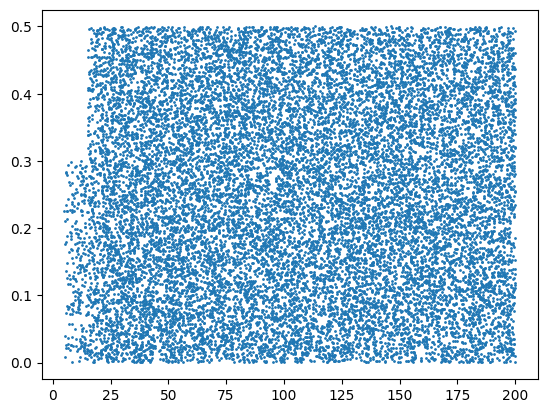

In [5]:
plt.plot(df['mass1'], df['eccentricity'], 'o', ms=1)

In [6]:
inj = gen_injections_pycbc()
df = pd.DataFrame(inj.rvs(100000))

In [7]:
df.loc[3]

mass1           194.562418
mass2            34.595131
spin1z            0.261365
spin2z            0.483184
eccentricity      0.043933
rel_anomaly       5.807410
Name: 3, dtype: float64

In [9]:
import logging
logging.info("Start generating waveforms %s", df.loc[3])

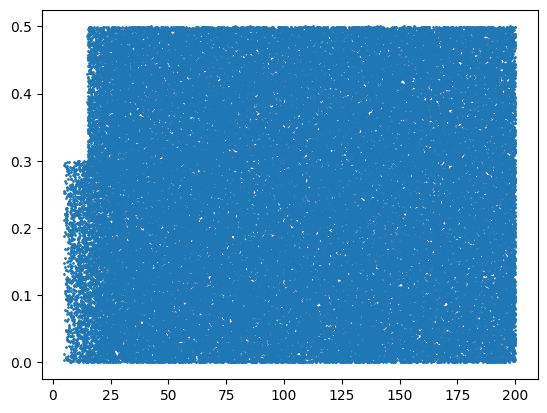

In [24]:
plt.plot(df['mass1'], df['eccentricity'], 'o', ms=1)

In [29]:
gen = GenWaveform(buffer_length = 32, sample_rate = 2048, f_lower = 20)

Read in template bank

In [30]:
with h5py.File('/work/yifanwang/ecc/src/searchtools/scripts/sucbankprodduration.hdf') as f:
        df_bank = pd.DataFrame(
           {'mass1': f['mass1'][:],
            'mass2': f['mass2'][:],
            'tau0': pycbc.conversions.tau0_from_mass1_mass2(f['mass1'][:],f['mass2'][:],15),
            'eccentricity': f['eccentricity'][:],
            'rel_anomaly': f['rel_anomaly'][:],
            'spin1z': f['spin1z'][:],
            'spin2z': f['spin2z'][:],
            'approximant': f['approximant'][:].astype('str'),
            'f_lower': f['f_lower'][:],
            'template_duration': f['template_duration'][:],}
        )
df_bank['index'] = df_bank.index

In [31]:
df_bank

,mass1,mass2,tau0,eccentricity,rel_anomaly,spin1z,spin2z,approximant,f_lower,template_duration,index
0,64.061093,85.262889,0.459226,0.167525,1.997884,0.000620,-0.081165,SEOBNRv5E,20.0,0.141113,0
1,68.060491,28.587619,1.115139,0.259024,2.260746,0.176357,-0.226991,SEOBNRv5E,20.0,0.329590,1
2,59.947013,61.584384,0.634350,0.031182,1.161729,0.481824,0.420913,SEOBNRv5E,20.0,0.286133,2
3,43.772996,61.903602,0.824914,0.291899,2.723562,-0.367094,0.328200,SEOBNRv5E,20.0,0.228516,3
4,59.499551,76.280133,0.535416,0.234504,1.573280,0.164777,-0.268736,SEOBNRv5E,20.0,0.150879,4
...,...,...,...,...,...,...,...,...,...,...,...
730282,5.025893,5.011645,40.490520,0.179931,3.562414,-0.170420,-0.087774,SEOBNRv5E,20.0,16.978027,730282
730283,5.020360,5.006370,40.563286,0.295819,1.262575,0.365476,0.431696,SEOBNRv5E,20.0,14.226562,730283
730284,5.001911,5.000287,40.729157,0.150412,0.685238,0.282719,0.463015,SEOBNRv5E,20.0,18.084473,730284
730285,5.013018,5.012965,40.568248,0.172876,3.767090,0.117018,-0.025586,SEOBNRv5E,20.0,17.303223,730285


In [39]:
inj = gen_injections()

df_inj = pd.DataFrame(inj.rvs(500))

df_inj['tau0'] = pycbc.conversions.tau0_from_mass1_mass2(df_inj['mass1'],df_inj['mass2'],15)
df_inj['index'] = df_inj.index
df_inj['approximant'] = df_bank['approximant'][0]
df_inj['f_lower'] = df_bank['f_lower'][0]
df_inj['s'] = np.zeros(df_inj.shape[0])


inj_waveform = {}
parlist = ['index', 'approximant', 'f_lower', 'mass1', 'mass2', 'spin1z', 'spin2z', 'eccentricity', 'rel_anomaly']

with multiprocessing.Pool(128) as pool:
    for return_i, return_hp in pool.imap_unordered(
        wf_wrapper,
        ({k: df_inj.loc[idx,k] for k in parlist} for idx in tqdm(df_inj.index))
    ):
        inj_waveform[return_i] = return_hp
        try:
            df_inj.loc[return_i, 's'] = return_hp.s
        except AttributeError:
            df_inj.loc[return_i, 's'] = np.nan

df_inj.to_csv('figure/studymatch/injections.csv', index=False)

100%|██████████| 100/100 [00:00<00:00, 3820.99it/s]WARNING:pyseobnr.models.SEOBNRv5EHM:The predicted starting separation of the system (r_start = 9.573044068152168) is below the minimum starting separation allowed by the model (r_start_min = 10.0). Integrating backwards in time a set of secular evolution equations to obtain a prediction for the starting separation larger than this minimum. This will change the starting input values of the system.
ERROR:pyseobnr.eob.dynamics.integrate_ode_ecc:Internal function call failed: Input domain error. The time length of the dynamics is below 200 M. Aborting waveform generation since this could cause non-physical waveforms or problems in subsequent steps of the model. Please, review the physical sense of the input parameters.
ERROR:pyseobnr.models.SEOBNRv5EHM:Waveform generation failed for q = 1.0882583416279166, chi_1 = -0.29964832859437174, chi_2 = 0.07238143758603022, omega_avg = 0.045399153510136604, omega_inst = 0.03128941767113013, eccentri

Internal function call failed: Input domain error. The time length of the dynamics is below 200 M. Aborting waveform generation since this could cause non-physical waveforms or problems in subsequent steps of the model. Please, review the physical sense of the input parameters.


ERROR:pyseobnr.eob.dynamics.integrate_ode_ecc:Internal function call failed: Input domain error. The time length of the dynamics is below 200 M. Aborting waveform generation since this could cause non-physical waveforms or problems in subsequent steps of the model. Please, review the physical sense of the input parameters.
ERROR:pyseobnr.models.SEOBNRv5EHM:Waveform generation failed for q = 1.5538981055637633, chi_1 = -0.3084238196508394, chi_2 = 0.2783947434050388, omega_avg = 0.0446762787049305, omega_inst = 0.028725894577317834, eccentricity = 0.27039839054510395, rel_anomaly = 3.381108438655675. 


Internal function call failed: Input domain error. The time length of the dynamics is below 200 M. Aborting waveform generation since this could cause non-physical waveforms or problems in subsequent steps of the model. Please, review the physical sense of the input parameters.


In [33]:
def study_match(hpinj, hpinj_tau0, df_bank, tau0_tol=0.5, nproc=128):
    if hpinj == None:
        print("Failed waveform generation in injection")
        return None
    
    neighbor = df_bank[abs(df_bank['tau0'] - hpinj_tau0) < tau0_tol].index
    print("Number of FF jobs =", len(neighbor)) 

    all_fitting_factors = []
    parlist = ['index', 'approximant', 'f_lower', 'mass1', 'mass2', 'spin1z', 'spin2z', 'eccentricity', 'rel_anomaly']
    with multiprocessing.Pool(nproc) as pool:
        for return_i, return_hp in pool.imap_unordered(
            wf_wrapper,
            ({k: df_bank.loc[idx, k] for k in parlist} for idx in tqdm(neighbor))
        ):
            match = gen.match(hpinj, return_hp)
            dict_current = {'bank_row': return_i, 
                            'fittingfactor': match, 
                            'bank_s': return_hp.s,
                            }
            all_fitting_factors += [dict_current]
        
    return all_fitting_factors

In [34]:
for ii in range(500):
    hpinj = inj_waveform[ii]
    _, hpinj_duration = tdwf_wrapper({k: df_inj.loc[ii,k] for k in parlist})
    hpinj_tau0 = df_inj.loc[ii, 'tau0']
    if hpinj == None:
        print("Failed waveform generation in injections for #", ii)
        continue
    
    allff = study_match(hpinj, hpinj_tau0, df_bank, tau0_tol = 0.5, nproc = 128)
    df_ff = pd.DataFrame(allff)

    df_ff_sorted = df_ff.sort_values('fittingfactor', ascending=False)
    max_index = df_ff_sorted['fittingfactor'].idxmax()
    df_merged = df_ff_sorted.merge(df_bank, left_on='bank_row', right_index=True)
    df_merged.to_csv('figure/studymatch/FF_'+str(ii)+'.csv',index=False)
    
    plt.figure()
    plt.scatter(df_merged['template_duration']-hpinj_duration, 1 - df_merged['fittingfactor'], 
            c=df_merged['tau0'] - hpinj_tau0, s=1)
    plt.colorbar(label='Template Tau0 - Injection Tau0')
    plt.axhline(0.05, color='r', linestyle='--')
    plt.ylabel('1 - Fitting Factor')
    plt.yscale('log')
    #plt.ylim(upp=0.9)
    plt.xlabel('Template Duration - Injection Duration')
    plt.title('Injection duration = '+str(hpinj_duration)+', Injection Tau0 = '+str(hpinj_tau0))
    plt.savefig('figure/studymatch/FF_'+str(ii)+'.png',dpi=100)

    plt.figure()
    plt.scatter(df_merged['template_duration']-hpinj_duration, 1 - df_merged['fittingfactor'], 
            c=df_merged['bank_s'] / hpinj.s, s=1)
    plt.colorbar(label='Template sigma / Injection sigma')
    plt.axhline(0.05, color='r', linestyle='--')
    plt.ylabel('1 - Fitting Factor')
    plt.yscale('log')
    #plt.ylim(upp=0.9)
    plt.xlabel('Template Duration - Injection Duration')
    plt.title('Injection sigma = '+str(hpinj.s))
    plt.savefig('figure/studymatch/FF_'+str(ii)+'_sigma.png',dpi=100)


Number of FF jobs = 12977


100%|██████████| 12977/12977 [04:15<00:00, 50.74it/s]WARNING:pyseobnr.models.SEOBNRv5EHM:The new starting input values of the system are: eccentricity = 0.29929054718369785, rel_anomaly = 4.572985001883727, omega_avg = 0.03162538133368853.



Number of FF jobs = 6911


100%|██████████| 6911/6911 [01:22<00:00, 83.59it/s] WARNING:pyseobnr.models.SEOBNRv5EHM:The predicted starting separation of the system (r_start = 8.001442270281432) is below the minimum starting separation allowed by the model (r_start_min = 10.0). Integrating backwards in time a set of secular evolution equations to obtain a prediction for the starting separation larger than this minimum. This will change the starting input values of the system.



Study #6

In [54]:
%matplotlib inline

In [55]:
df = pd.read_csv('figure/studymatch/injections.csv')

In [56]:
_, hf = wf_wrapper({k: df.loc[6,k] for k in parlist})

In [57]:
hf

In [58]:
ht = hf.to_timeseries()

In [59]:
plt.plot(ht.sample_times, ht)